#### Дифференцирование в контексте машинного обучения и прикладной математики в целом

Рассмотрим логистическую регрессию:

\begin{equation*}
  z = wx + b, \; \; y = σ(z)
\end{equation*}


\begin{equation*}
  \mathcal{L} = \frac{1}{2} (y-t)^2
\end{equation*}

где у нас $x$ - матрица признаков, $\sigma(z) = \frac{1}{1+e^{-x}}$ - сигмоида, $w, b$ - параметры модели, $t$ - целевая переменная.

\begin{equation*}
  \frac{d\mathcal{L}}{dy} = y − t
\end{equation*}

\begin{equation*}
  \frac{d\mathcal{L}}{dz} = σ′(z) \frac{d\mathcal{L}}{dy} 
\end{equation*}

\begin{equation*}
  \frac{\partial \mathcal{L}}{\partial w} = \frac{d\mathcal{L}}{dz} x, \; \; \frac{\partial \mathcal{L}}{\partial b} = \frac{d\mathcal{L}}{dz}
\end{equation*}

Общий случай: оптимизация параметрической функции. 

**Задачи**: регрессия, бинарная классификация, многоканальная классификация;

**Модели/архитектуры**: линейная, логарифмически линейная, многослойный персептрон;

**Функции потерь**: квадратичная ошибка, лосс 0–1, кросс-энтропия, hinge loss;

**Алгоритмы оптимизации**: прямое решение, градиентный спуск, персептрон;

Методы дифференцирования:

- Символьное дифференцирование (Wolfram Mathematica, Maple, Matlab, etc.)

- Численное дифференцирование (конечно-разностные схемы, метод Савицкого-Голая, etc.)

- Автоматическое дифференцирование (Tensorflow, Torch)

#### Рассмотрим методы численного дифференцирования:

In [4]:
import numpy as np
from typing import Callable, Union

import matplotlib.pyplot as plt
import matplotlib.colors as colors

Метод конечных разностей позволяет определить (точнее, приближенно получить) производную функции $f(x)$. По определению, производная - предел отношения приращения функции к приращению аргумента при стремящемся к нулю приращению:


\begin{equation*}
  f'(x) = \lim_{\Delta x ⟶ 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}
\end{equation*}

Из теоремы Лагранжа о среднем значении дифференцируемой функции выводится ряд Тейлора для аналитической функции:

\begin{equation*}
  f(x + \Delta x) = \sum_{n = 0}^{+ ∞} \frac{f^{(n)}(x)}{n!}(\Delta x)^{n}
\end{equation*}

Из многочлена Тейлора первой степени (т.е. до слагаемого, содержащего производную) и используя форму Пеано для асимптотической записи остаточного члена (т.е. остаточный член - б.м. функция высшего порядка, чем $\Delta x$ при $\Delta x ⟶ 0$) получаем:

\begin{equation*}
  f(x + \Delta x) = f(x) + f'(x) \Delta x + o(\Delta x)
\end{equation*}

Отсюда можно приближённо выразить производную в точке $x$, переходя от дифференциального оператора к разностному оператору:

\begin{equation*}
  f'(x) ≈ \frac{f(x + \Delta x) - f(x)}{\Delta x} 
\end{equation*}

Погрешность аппроксимации производной можно уменьшить, используя не "правую схему", а "центральную", т.к. она имеет остаточный член $o(\Delta x^2)$:

\begin{equation*}
  f'(x) ≈ \frac{f(x + \Delta x) - f(x - \Delta x)}{2 \Delta x}.
\end{equation*}

In [2]:
def shifted_point(point, shift, dim):
  new_point = np.copy(point)
  new_point[dim] += shift
  return new_point

def finite_difference_deriv(function : Callable[[np.ndarray,], float], point : Union[np.ndarray, float], 
                            delta : float, dim : int, method : str = 'central') -> float:
  if isinstance(point, float):
    point = np.array([point,])
  incr_forward = shifted_point(point, delta, dim)
  if method == 'central':
    incr_backward = shifted_point(point, - delta, dim)
    return (function(incr_forward) - function(incr_backward)) / (2 * delta)
  if method == 'forward':
    return (function(incr_forward) - function(point)) / (delta)

Градиент скалярной функции $f : \mathbb{R}^{n} \longrightarrow \mathbb{R}$ нескольких переменных $\mathbf{x}$ - вектор-функция $\nabla f : \mathbb{R}^{n} \longrightarrow \mathbb{R}^{n}$, чьи значения - частные производные функции $f$ в точке $\mathbf{p}$.

\begin{equation*}
  \nabla f = 
  \left[\begin{array}{cc}
   \frac{\partial f}{\partial x_1}(\mathbf{p}) \\
   \vdots   \\
  \frac{\partial f}{\partial x_n}(\mathbf{p}) \\
  \end{array}
  \right]
\end{equation*}

Аналогично определим Гессиан - матрицу вторых производных: $H_{ij} = \frac{\partial^2 f}{\partial x_i x_j}$ в точке $\mathbf{p}$:

\begin{equation*}
\begin{bmatrix}
 \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 x_2} & ... & \frac{\partial^2 f}{\partial x_1 x_n} \\
  \frac{\partial^2 f}{\partial x_2 x_1} & \frac{\partial^2 f}{\partial x_2^2} & ... & \frac{\partial^2 f}{\partial x_2 x_n} \\
  & ... \\
  \frac{\partial^2 f}{\partial x_n x_1} & \frac{\partial^2 f}{\partial x_n x_2} & ... & \frac{\partial^2 f}{\partial x_n^2} \\
\end{bmatrix}
\end{equation*}

Конечно-разностная схема для определения смешанной производной по переменным $x_i$ и $x_j$ имеет следующую форму:

\begin{equation*}
\frac{\partial^2 f}{\partial x_i x_j} ≈ \frac{f(x + e_i h + e_j h) - f(x + e_i h - e_j h) - f(x - e_i h + e_j h) + f(x - e_i h - e_j h)}{4 h^2}.
\end{equation*}

In [3]:
def hessian(function : Callable[[np.ndarray,], float], initial : Union[np.ndarray, float], 
            delta : float =1e-3) -> np.ndarray:
  initial = np.array(initial, dtype=float)
  n = len(initial)
  output = np.matrix(np.zeros(n*n))
  output = output.reshape(n,n)
  for i in range(n):
    for j in range(n):
      ei = np.zeros(n)
      ei[i] = 1
      ej = np.zeros(n)
      ej[j] = 1
      f1 = function(initial + delta * ei + delta * ej)
      f2 = function(initial + delta * ei - delta * ej)
      f3 = function(initial - delta * ei + delta * ej)
      f4 = function(initial - delta * ei - delta * ej)
      numdiff = (f1-f2-f3+f4)/(4*delta*delta)
      output[i,j] = numdiff
  return output

In [4]:
func = np.cos
scheme = np.vectorize(finite_difference_deriv, excluded = {'function', 'delta', 'dim', 'method'})

x = np.linspace(0, 2 * np.pi, 100)
y = func(x)
deriv_analytical = -np.sin(x)
deriv_numerical = scheme(function = func, point = x, delta = np.pi/100., dim = 0)

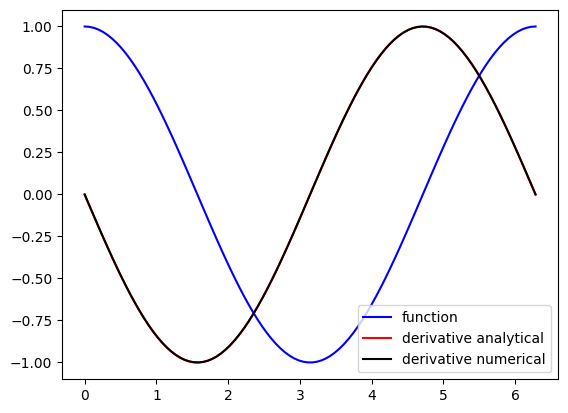

In [5]:
plt.plot(x, y, color = 'b', label = 'function')
plt.plot(x, deriv_analytical, color = 'r', label = 'derivative analytical')
plt.plot(x, deriv_numerical, color = 'k', label = 'derivative numerical')
plt.legend()

In [6]:
print(f'Mean absolute error is {np.mean(np.abs(deriv_analytical - deriv_numerical))}

Mean absolute error is 0.00010365874208513802


In [7]:
def compare_with_analytical(delta, method):
  deriv_approx = scheme(function = func, point = x, delta = np.pi*delta, dim = 0, method = method)
  return np.mean(np.abs(deriv_analytical - deriv_approx))

central_derivs = []; forward_derivs = []
for delta_frac in np.logspace(-10, -2, 1000):
  central_derivs.append([delta_frac, compare_with_analytical(delta_frac, 'central')])
  forward_derivs.append([delta_frac, compare_with_analytical(delta_frac, 'forward')])

In [8]:
central_derivs_a = np.array(central_derivs)
forward_derivs_a = np.array(forward_derivs)
central_derivs_a.shape

(1000, 2)

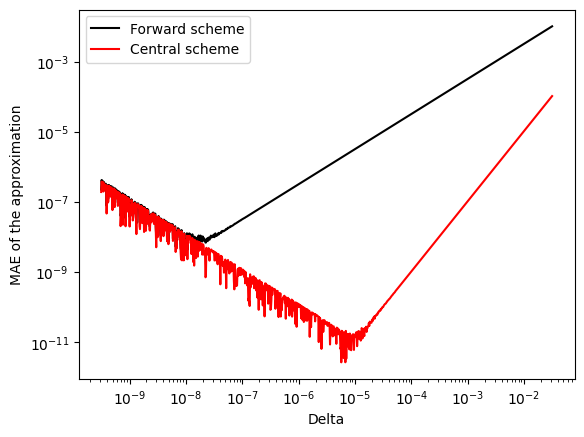

In [9]:
plt.plot(forward_derivs_a[:, 0]*np.pi, forward_derivs_a[:, 1], color = 'k', label = 'Forward scheme')
plt.plot(central_derivs_a[:, 0]*np.pi, central_derivs_a[:, 1], color = 'r', label = 'Central scheme')
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Delta')
plt.ylabel('MAE of the approximation')
plt.legend()

Альтернативные численные аппроксимации производных: 
- адаптация под использование повышенного числа точек для повышения порядка аппроксимации и возможность использовать произвольные сетки https://www.ams.org/journals/mcom/1988-51-184/S0025-5718-1988-0935077-0/;
- фильтрация Савицкого-Голая: представление данных полиномами и их последующее дифференцирование на основе аналитических выражений; 
- спектральные методы.

**Градиентный спуск:**
Mетод нахождения локального (а в случае выпуклой функции, соответственно, глобального) оптимума путём последовательного движения вдоль градиента. Метод - первого порядка, требует лишь первые производные, в отличии от методов второго порядка, например, BFGS. 

$\mathbf{x}_{j+1} = \mathbf{x}_{j+1} - \alpha \nabla f(\mathbf{x}_{j+1})$

Модификации градиентного спуска: https://arxiv.org/abs/1609.04747, общеупотребимая в текущий момент момент - Adam optimizer https://arxiv.org/abs/1412.6980

Вопрос в том, как задавать градиент. Для аналитически-дифференцируемых функций берём значения производных, определённые аналитически, но что если бы мы в ситуации, когда производные - неизвестны. Решение - заменить их на частные производные, полученные по конечным разностям.  

In [10]:
def numerical_GD(func, initial_position = None, step_coeff = 1e-3, scheme = 'central', delta = 1e-4, stop_cond = None):
  hist = [initial_position,]
  grad_hist = []
  pos = initial_position
  stop_cond_satisfied = False
  def default_stop_cond(pos_new, pos_prev):
    return np.linalg.norm(np.abs(pos_new - pos_prev)) < 1e-6

  if stop_cond is None:
    stop_cond = default_stop_cond

  while not stop_cond_satisfied:
    grad_vector = np.array([finite_difference_deriv(func, point = pos, delta = delta, dim = dim, method=scheme) 
                            for dim in range(len(initial_position))])
    pos_prev = np.copy(pos)
    pos = pos - step_coeff * grad_vector

    grad_hist.append(grad_vector)    
    hist.append(pos)
    stop_cond_satisfied = stop_cond(pos, pos_prev)

  return pos, np.array(hist), np.array(grad_hist)

Для начала рассмотрим "простую" функцию - функцию Розенброка :

\begin{equation*}
f(x, y) = (1 - x)^2 + 100(y - x^2)^2
\end{equation*}

Можно ли применять к ней градиентный спуск? Достижение глобального оптимума обеспечено лишь для выпуклых функций (одномерный случай: $f: \mathbb{R} \longrightarrow \mathbb{R}$): $\forall x, y$ и параметра $\lambda \in [0, 1]$

\begin{equation*}
f(\lambda x + (1 - \lambda) y) \leq \lambda f(x) + (1 - \lambda) f(y) 
\end{equation*}

Однако, есть класс функций, для которых нет локальных оптимумов и, соответственно, нет связанных рисков схождения к ним, однако допускаются "стационарные точки", где $\frac{df}{dx} = 0$ - квазивыпуклые функции: $\forall x, y \in X$, $X$ - произвольное выпуклое подмножетсво области определения $f$ 

\begin{equation*}
f(\lambda x + (1 - \lambda) y) \leq max(f(x), f(y)) 
\end{equation*}

Или, что эквивалентно, для дифференцируемых функций (а мы работаем с дифференцируемыми):

\begin{equation*}
f(y) \leq f(x) \Rightarrow  f'(x) (y - x) \leq 0 \; \forall x, y \in X.
\end{equation*}

Выпуклость функции дважды-дифференцируемой функции можно проверить при помощи "теста второй производной": матрица Гессе выпуклой функции положительно полуопределена.

Проверка критических точек: если гессиан положительно определен в точке $x$ - критической, то $f$ достигает изолированного локального минимума в этой точке. Если гессиан отрицательно определен в точке $x$, то $f$ достигает изолированного локального максимума в точке $x$. Если гессиан имеет как положительные, так и отрицательные собственные значения, то x является седловой точкой для f . В противном случае тест не дает результатов. Это означает, что в локальном минимуме гессиан является положительно-полуопределенным, а в локальном максимуме гессиан является отрицательно-полуопределенным.

In [11]:
def func(x):
  return (1-x[0])**2 + 100 * (x[1] - x[0]**2)**2

In [12]:
x1 = np.linspace(-1, 2, 1000); x2 = np.linspace(-1, 2, 1000)
grids = np.meshgrid(x1, x2, indexing = 'ij') # np.stack()

In [13]:
func_v = np.vectorize(func)
res = np.empty_like(grids[0])
for idx, _ in np.ndenumerate(grids[0]):
  res[idx] = func((grids[0][idx], grids[1][idx]))
res.shape

(1000, 1000)

In [27]:
def Heatmap(matrix, path = None, interval = None, use_norm = False, area = ((0, 1), (0, 1)), xlabel = '', ylabel = '', figsize=(8,6), title = ''):
    y, x = np.meshgrid(np.linspace(area[0][0], area[0][1], matrix.shape[0]), np.linspace(area[1][0], area[1][1], matrix.shape[1]))
    fig, ax = plt.subplots(figsize = figsize)
    plt.xlabel(xlabel)
    ax.set(ylabel=ylabel)
    ax.xaxis.labelpad = -10


    if interval:
        c = ax.pcolormesh(x, y, np.transpose(matrix), cmap='RdBu', vmin=interval[0], vmax=interval[1])    
    else:
      if use_norm:
        norm=norm=colors.SymLogNorm(linthresh=0.03, linscale=0.03,
                                                  vmin=-1.0, vmax=1.0, base=10)      
        c = ax.pcolormesh(x, y, np.transpose(matrix), cmap='RdBu', vmin=min(-abs(np.max(matrix)), -abs(np.min(matrix))),
                          vmax=max(abs(np.max(matrix)), abs(np.min(matrix))), norm = norm) 
      else:
        c = ax.pcolormesh(x, y, np.transpose(matrix), cmap='RdBu', vmin=min(-abs(np.max(matrix)), -abs(np.min(matrix))),
                          vmax=max(abs(np.max(matrix)), abs(np.min(matrix)))) 

    # set the limits of the plot to the limits of the data
    ax.axis([x.min(), x.max(), y.min(), y.max()])
    if path is not None:
      plt.plot(path[:, 0], path[:, 1], color = 'k')
    fig.colorbar(c, ax=ax)
    plt.title(title)
    plt.show()

In [28]:
point, hist, grad_hist = numerical_GD(func, initial_position = [0., 0.])


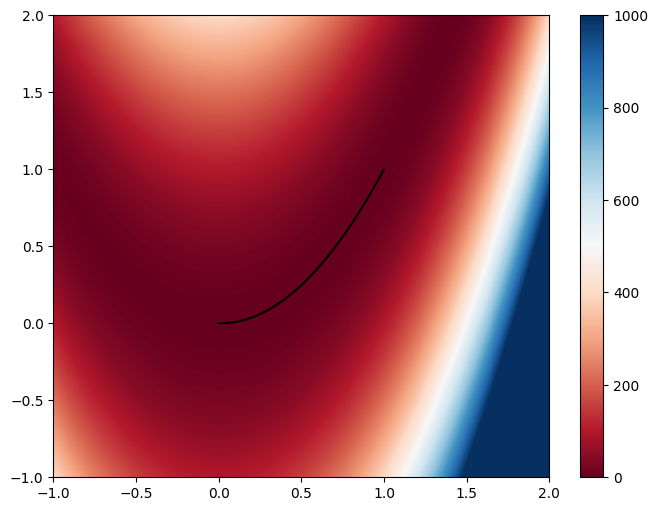

In [31]:
Heatmap(res.T, path = hist, area = ((-1, 2), (-1, 2)), interval=[0, 1000])

In [32]:
print(point)

[0.99888165 0.99776008]


In [33]:
point, hist, grad_hist = numerical_GD(func, initial_position = [-1.5, -0.75])

In [34]:
print(point)

[0.99888146 0.99775969]


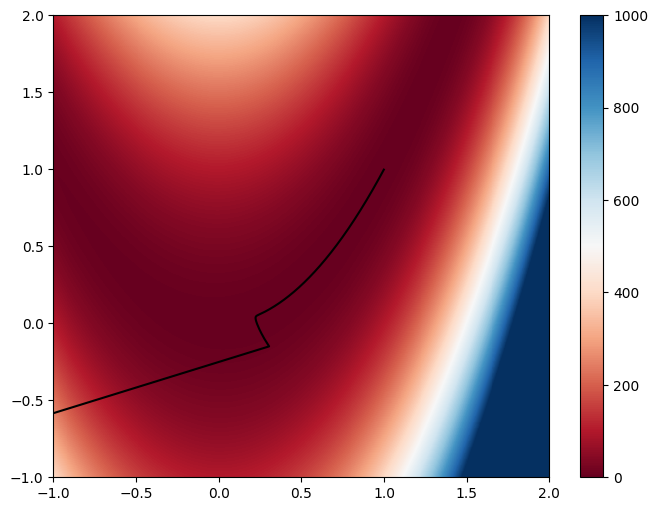

In [35]:
Heatmap(res.T, path = hist, area = ((-1, 2), (-1, 2)), interval=[0, 1000])

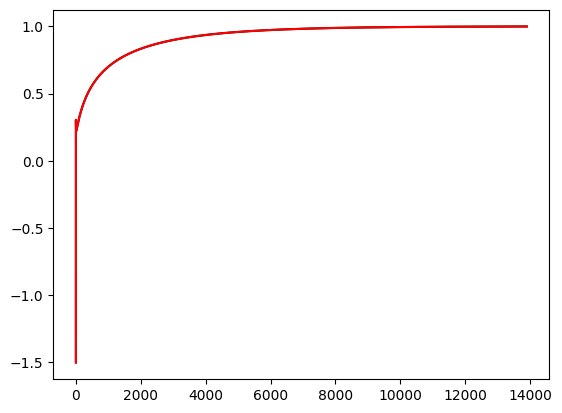

In [36]:
plt.plot(hist[:, 0], color = 'k')
plt.plot(hist[:, 0], color = 'r')

In [37]:
point, hist, grad_hist = numerical_GD(func, initial_position = [-3.5, -3.75])

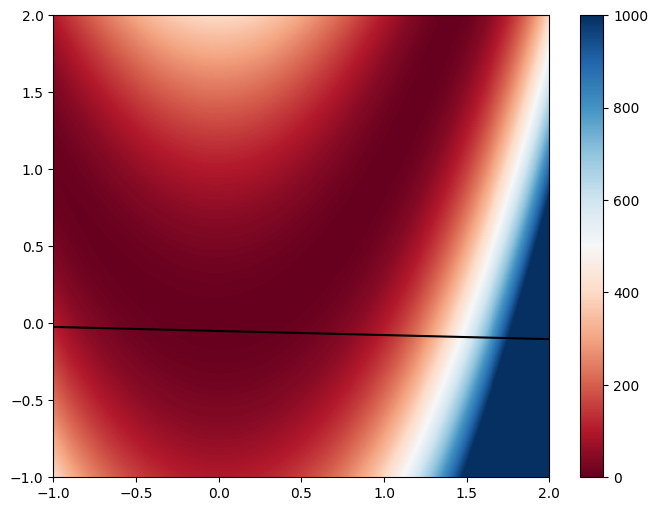

In [38]:
Heatmap(res.T, path = hist, area = ((-1, 2), (-1, 2)), interval=[0, 1000])

In [39]:
point, hist, grad_hist = numerical_GD(func, initial_position = [-3.5, -3.75], step_coeff = 1e-6)

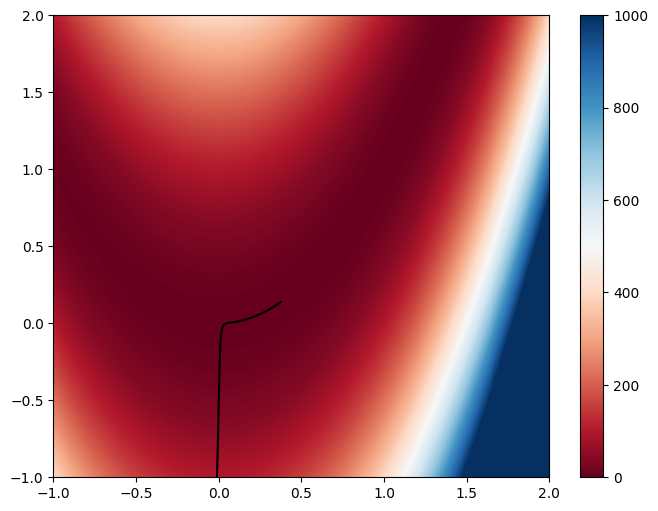

In [40]:
Heatmap(res.T, path = hist, area = ((-1, 2), (-1, 2)), interval=[0, 1000])

Рассмотрим пример более вычислительно-сложной функции с заданным аналитически градиентом: 

\begin{equation}

f(x, y) = -(y+47) \sin{\sqrt{ | \frac{x}{2} + y+47 |}}-x*\sin{\sqrt{|x - y + 47|}}

\end{equation}

In [27]:
def function(x):
    return -(x[1]+47)*np.sin(np.sqrt(np.abs(x[0]/2+(x[1]+47))))-x[0]*np.sin(np.sqrt(np.abs(x[0]-(x[1]+47))))

def gradient(x):
    a1=np.abs(47-x[0]+x[1])
    s1=np.sign(47-x[0]+x[1])
    a2=np.abs(x[0]/2+(x[1]+47))
    s2=np.sign(x[0]/2+(x[1]+47))
    t1=(x[0]/2)*np.cos(np.sqrt(a1))/np.sqrt(a1)
    t2=(47+x[1])/4*np.cos(np.sqrt(a2))/np.sqrt(a2)
    t3=np.sin(np.sqrt(a1))
    t4=np.sin(np.sqrt(a2))
    dfx=s1*t1-s2*t2-t3
    dfy=-s1*t1-2*s2*t2-t4
    return np.array([dfx, dfy])    

In [28]:
def numerical_GD(func, grad_analytical = None, initial_position = None, step_coeff = 1e-3, 
                 scheme = 'central', delta = 1e-4, stop_cond = None):
  hist = [initial_position,]
  grad_hist = []
  pos = initial_position
  stop_cond_satisfied = False
  def default_stop_cond(val_new, val_prev):
    return np.linalg.norm(np.abs(val_new - val_prev)) < 1e-6

  if stop_cond is None:
    stop_cond = default_stop_cond

  while not stop_cond_satisfied:
    if grad_analytical is None:
      grad_vector = np.array([finite_difference_deriv(func, point = pos, delta = delta, dim = dim, method = scheme) 
                              for dim in range(len(initial_position))])
    else:
      grad_vector = grad_analytical(pos)
    pos_prev = np.copy(pos)
    pos = pos - step_coeff * grad_vector

    grad_hist.append(grad_vector)    
    hist.append(pos)
    stop_cond_satisfied = stop_cond(func(pos), func(pos_prev))

  return pos, np.array(hist), np.array(grad_hist)

In [29]:
x = np.arange(0,512,0.3)
y = np.arange(0,512,0.3)
XX , YY = np.meshgrid(x,y)

res = np.empty_like(XX)
for idx, _ in np.ndenumerate(XX):
  res[idx] = function((XX[idx], YY[idx]))

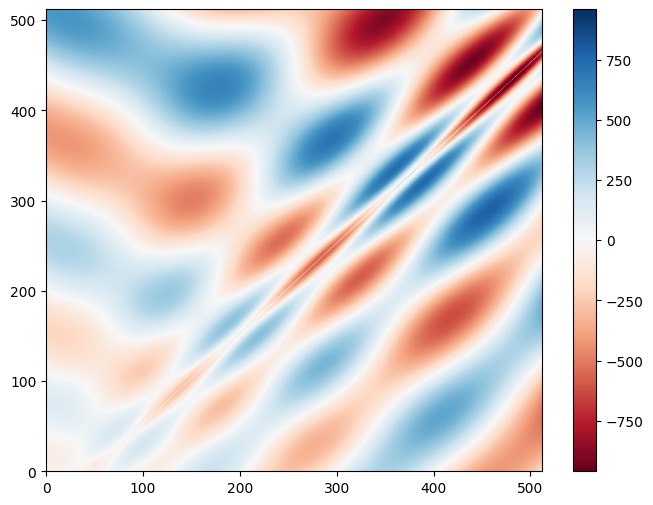

In [30]:
Heatmap(res, area = ((0,512), (0,512)))

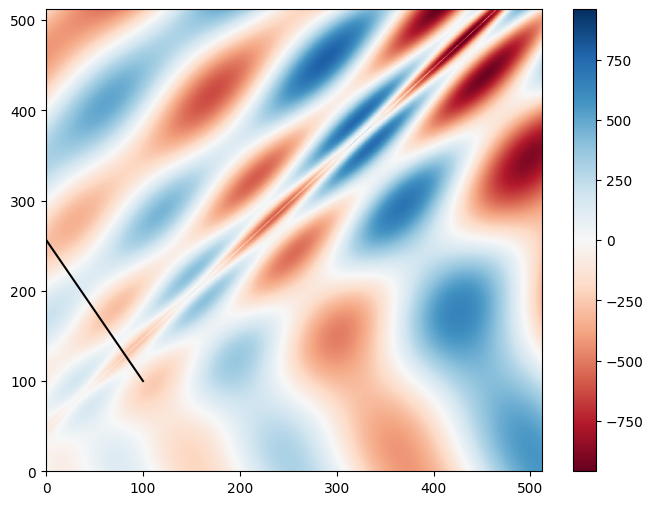

In [31]:
point, hist, grad_hist = numerical_GD(function, initial_position = [100, 100], step_coeff = 1e-2)
Heatmap(res.T, path = hist, area = ((0,512), (0,512)))

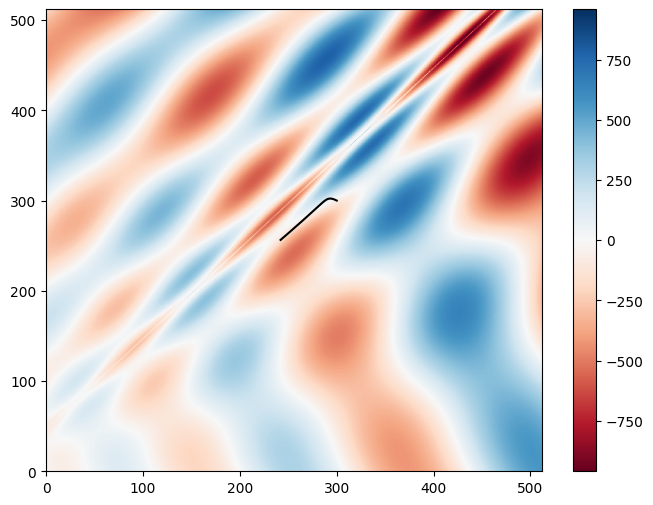

In [32]:
point, hist, grad_hist = numerical_GD(function, grad_analytical = gradient, initial_position = [300, 300], step_coeff = 1e-1)
Heatmap(res.T, path = hist, area = ((0,512), (0,512)))

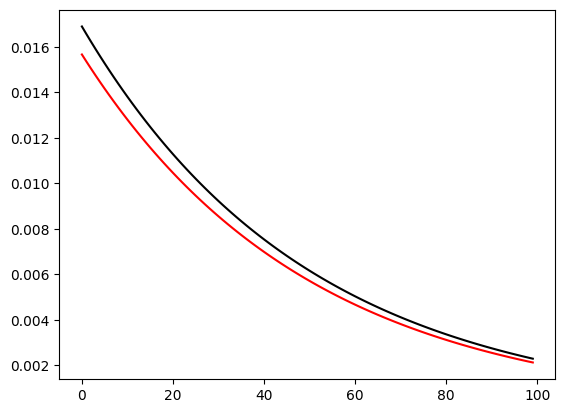

In [33]:
plt.plot(grad_hist[-100:, 0], color = 'k')
plt.plot(grad_hist[-100:, 1], color = 'r')

In [34]:
# Примеры базовых методов оптимизации в стандартной "экосистеме" Python:

from scipy.optimize import minimize
from scipy.optimize import differential_evolution

#### Автоматическое дифференцирование:

Это семейство методов, похожих на метод обратного распространения, (а точнее, их обобщение) для эффективной и точной оценки производных числовых функций, выраженных через программный код.

Рассмотрим пример функции $y = f (x_1, x_2) = ln(x_1) + x_1 x_2 − sin(x_2)$  https://www.jmlr.org/papers/volume18/17-468/17-468.pdf

**Прямой режим (Forward mode):** последовательное вычисление производных функций, входящих в сложную функцию, начиная с входных аргументов на основе правила дифф. сложной функции (chain rule).

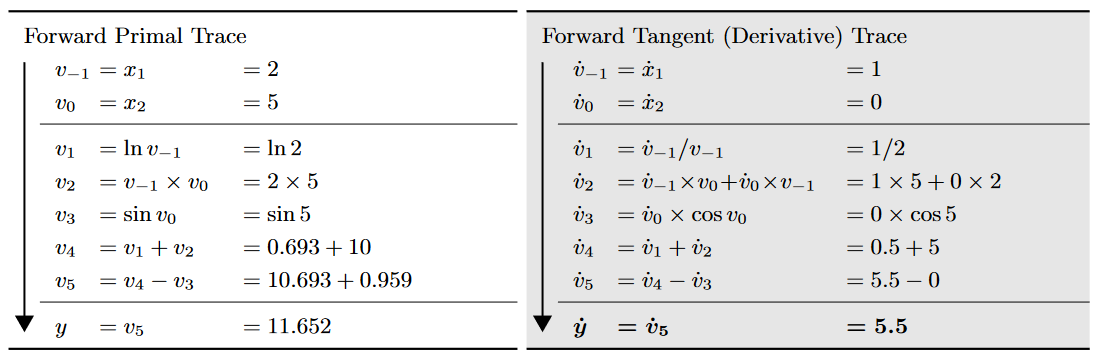

**Обратный режим (Inverse mode):** производные вычисляются на основе двухфазного процесса. 
В первой фазе исходный код функции выполняется вперед, заполняя промежуточные переменные $v_i$ и записывая зависимости в вычислительном графике в промежуточные переменные. Во второй фазе производные вычисляются путем последовательного вычисления множителей в рамках сопряженных $v_i$ в обратном направлении, от выходов к входам.

К каждой промежуточной переменной $v_i$ вводится присоединенная $\overline{v}_{i} = \frac{\partial y_{j}}{\partial v_{i}}$. Она представляет чувствительность рассматриваемого выхода $y_j$ по отношению к изменениям в $v_i$.

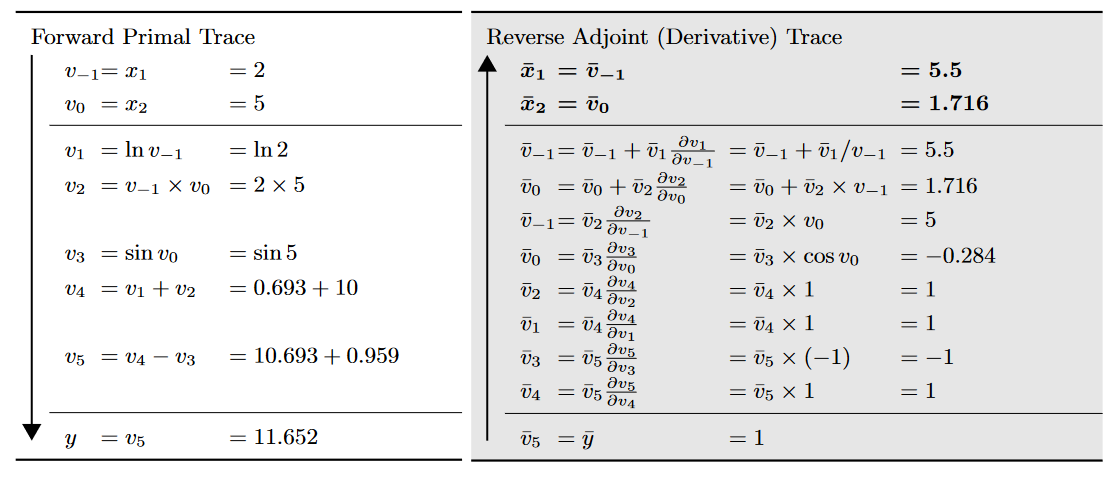

In [38]:
# Пример функции f(x) = 64 x (1 − x) (1 − 2x)^2 (1 − 8x + 8x^2)^2

def f(x):
    v = x
    for i in range(3):
        v = 4*v*(1 - v)
    return v

def df(x):
    v, dv = x, 1
    for i in range(3):
        v, dv = 4*v*(1-v), 4*dv-8*v*dv
    return (v, dv)

In [39]:
df(1)

(0, -64)

Как считаются градиенты на практике, в процессе обучения нейронных сетей? Рассмотрим пример простой полносвязной нейронной сети: применяем метод автоматического дифференцирования **(Какой и почему?)**.

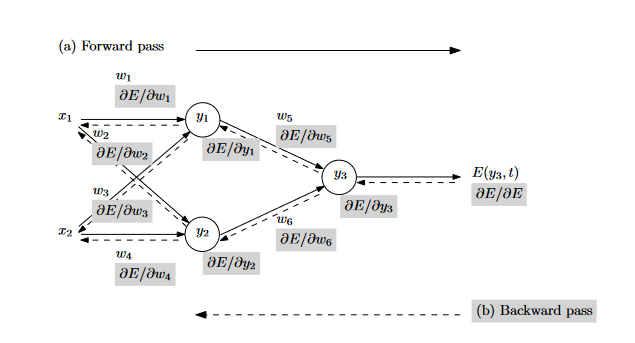

In [35]:
import random
import math

In [1]:
# Используем сигмоидальную функцию для выхода из нейронной сети
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Аналитическое выражение для производной сигмоидальной функции 
# dy = sigmoid(y) * (1.0 - sigmoid(y)), где y = 1/(1 + exp(-x))
# На вход принимаем преобразованные сигмоидой аргументы
def dsigmoid(y):
    return y * (1.0 - y) 

# Гиперболический тангенс как функция активации для скрытых слоёв   
def tanh(x):
    return math.tanh(x)
    
# Производная для tanh sigmoid
def dtanh(y):
    return 1 - y*y

class MLP_NN(object):
    """
    Реализация многослойного перцептрона из книги 'Programming Collective Intelligence' (http://shop.oreilly.com/product/9780596529321.do)
    Составлен из 3 слоёв: входного, скрытого (с tanh - ф. активации) и выходного. Количество входов и выходов должно соотв. задаче.
    Алгоритм - генерализован на произвольный датасет.
    Главное, чтобы формат входных данных был: [[[x1, x2, x3, ..., xn], [y1, y2, ..., yn]],
                                              [[[x1, x2, x3, ..., xn], [y1, y2, ..., yn]],
                                                 ...
                                              [[[x1, x2, x3, ..., xn], [y1, y2, ..., yn]]]
    """
    def __init__(self, input, hidden, output, iterations, learning_rate, momentum, rate_decay):
        """
        :param input: число входных нейронов
        :param hidden: число нейронов скрытого слоя
        :param output: число выходных нейронов
        """
        # initialize parameters
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.rate_decay = rate_decay
        
        # initialize arrays
        self.input = input + 1 # add 1 for bias node
        self.hidden = hidden
        self.output = output

        # set up array of 1s for activations
        self.ai = [1.0] * self.input
        self.ah = [1.0] * self.hidden
        self.ao = [1.0] * self.output

        # create randomized weights
        # use scheme from 'efficient backprop to initialize weights
        input_range = 1.0 / self.input ** (1/2)
        output_range = 1.0 / self.hidden ** (1/2)
        self.wi = np.random.normal(loc = 0, scale = input_range, size = (self.input, self.hidden))
        self.wo = np.random.normal(loc = 0, scale = output_range, size = (self.hidden, self.output))
        
        # create arrays of 0 for changes
        # this is essentially an array of temporary values that gets updated at each iteration
        # based on how much the weights need to change in the following iteration
        self.ci = np.zeros((self.input, self.hidden))
        self.co = np.zeros((self.hidden, self.output))

    def feedForward(self, inputs, wi = None, wo = None):
        """
        Алгоритм прямой связи проходит по всем узлам в скрытом слое и
        складывает все выходные данные из входного слоя, домножая их на веса.
        Выход каждого узла представляет собой сигмоидальную функцию от суммы 
        всех входных данных, которая затем передается на следующий слой.
        :param inputs: input data
        :return: обновленный вектор выходов нейронной сети
        """
        if len(inputs) != self.input-1:
            raise ValueError('Wrong number of inputs you silly goose!')

        # input activations
        for i in range(self.input -1): # -1 is to avoid the bias
            self.ai[i] = inputs[i]

        # hidden activations
        for j in range(self.hidden):
            sum = 0.0
            for i in range(self.input):
                sum += self.ai[i] * self.wi[i][j]
            self.ah[j] = tanh(sum)

        # output activations
        for k in range(self.output):
            sum = 0.0
            for j in range(self.hidden):
                sum += self.ah[j] * self.wo[j][k]
            self.ao[k] = sigmoid(sum)

        return self.ao[:]

    def backPropagate(self, targets):
        """
        Для выходного слоя
        1. Вычисляет разницу между выходным значением и целевым значением
        2. Получает производную сигмоидальной функции, чтобы определить, насколько должны измениться веса
        3. Обновляет веса для каждого нейрона на основе скорости обучения и производной sig

        Для скрытого слоя
        1. Вычисляет сумму силы каждой выходной связи, умноженную на то, насколько должен измениться целевой нейрон
        2. Получает производную, чтобы определить, насколько должны измениться веса
        3. Меняет веса на основе скорости обучения (learning rate'а) и производной
        :param targets: значения модел. переменной
        :param N: learning rate
        :return: обновлённые параметры нейронной сети
        """
        if len(targets) != self.output:
            raise ValueError('Wrong number of targets you silly goose!')

        # calculate error terms for output
        # the delta tell you which direction to change the weights
        output_deltas = [0.0] * self.output
        for k in range(self.output):
            error = -(targets[k] - self.ao[k])
            output_deltas[k] = dsigmoid(self.ao[k]) * error

        # calculate error terms for hidden
        # delta tells you which direction to change the weights
        hidden_deltas = [0.0] * self.hidden
        for j in range(self.hidden):
            error = 0.0
            for k in range(self.output):
                error += output_deltas[k] * self.wo[j][k]
            hidden_deltas[j] = dtanh(self.ah[j]) * error

        # update the weights connecting hidden to output
        for j in range(self.hidden):
            for k in range(self.output):
                change = output_deltas[k] * self.ah[j]
                self.wo[j][k] -= self.learning_rate * change + self.co[j][k] * self.momentum
                self.co[j][k] = change

        # update the weights connecting input to hidden
        for i in range(self.input):
            for j in range(self.hidden):
                change = hidden_deltas[j] * self.ai[i]
                self.wi[i][j] -= self.learning_rate * change + self.ci[i][j] * self.momentum
                self.ci[i][j] = change

        # calculate error
        error = 0.0
        for k in range(len(targets)):
            error += 0.5 * (targets[k] - self.ao[k]) ** 2
        return error

    def test(self, patterns):
        """
        Соотнести предсказания модели рядом с ожидаемыми классами. 
        """
        for p in patterns:
            print(p[1], '->', self.feedForward(p[0]))

    def train(self, patterns):
        # N: learning rate
        for i in range(self.iterations):
            error = 0.0
            random.shuffle(patterns)
            for p in patterns:
                inputs = p[0]
                targets = p[1]
                self.feedForward(inputs)
                error += self.backPropagate(targets)
            with open('error.txt', 'a') as errorfile:
                errorfile.write(str(error) + '\n')
                errorfile.close()
            if i % 10 == 0:
                print('error value is %-.5f' % error)
            # learning rate decay
            self.learning_rate = self.learning_rate * (self.learning_rate / (self.learning_rate + (self.learning_rate * self.rate_decay)))

    def predict(self, X):
        """
        Вывести предсказания модели после обучения
        """
        predictions = []
        for p in X:
            predictions.append(self.feedForward(p))
        return predictions

In [37]:
def load_data():
    data = np.loadtxt('sklearn_digits.csv', delimiter = ',')

    # first ten values are the one hot encoded y (target) values
    y = data[:,0:10]
    #y[y == 0] = -1 # if you are using a tanh transfer function make the 0 into -1
    #y[y == 1] = .90 # try values that won't saturate tanh
    
    data = data[:,10:] # x data
    #data = data - data.mean(axis = 1)
    data -= data.min() # scale the data so values are between 0 and 1
    data /= data.max() # scale
    
    out = []
    print(data.shape)

    # populate the tuple list with the data
    for i in range(data.shape[0]):
        part = list((data[i,:].tolist(), y[i].tolist()))
        out.append(part)

    return out

X = load_data()

print(X[9]) # make sure the data looks right

NN = MLP_NN(64, 100, 10, iterations = 50, learning_rate = 0.5, momentum = 0.5, rate_decay = 0.01)

NN.train(X)

NN.test(X)


(1797, 64)
[[0.0, 0.0, 0.6875, 0.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.125, 1.0, 1.0, 1.0, 0.8125, 0.0, 0.0, 0.0, 0.1875, 1.0, 0.75, 0.625, 0.875, 0.0, 0.0, 0.0, 0.0625, 1.0, 0.0625, 0.75, 0.9375, 0.0, 0.0, 0.0, 0.0, 0.8125, 1.0, 0.5625, 0.9375, 0.125, 0.0, 0.0, 0.0, 0.0, 0.1875, 0.0, 0.5625, 0.6875, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5625, 0.9375, 0.25, 0.0, 0.0, 0.0, 0.5625, 0.75, 0.8125, 0.1875, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]]
error value is 522.84752
error value is 121.78617
error value is 201.66477
error value is 74.40911
error value is 116.29008
[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] -> [2.9201920167047263e-10, 0.9971161896079798, 1.106938967213764e-11, 1.292129096386106e-18, 4.889172886071888e-10, 0.0001047494081848126, 1.8131523293676992e-07, 3.228217215239702e-14, 3.8188452161740006e-16, 5.7321050684654085e-31]
[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0] -> [0.003959613651290254, 4.722000306697905e-15, 6.635324892560131e-16, 1.449897328647387

**Итоги:** 

- Прямой режим: мы вычисляем градиенты вместе с результатом функции, в то время как обратный режим требует, чтобы мы сначала оценили функцию, а затем мы вычисляем градиенты, начиная с выхода.
Оба режима имеют свои плюсы и минусы, обратный режим - предпочтительный выбор при обучении нейронных сетей (и параметров моделей в целом) поскольку количество выходов меньше количества входов.

- Существует множество готовых реализаций. Например, https://github.com/HIPS/autograd или соответствующие подмодули различных deep-learning библиотек (torch.autograd, tensorflow.GradientTape, etc.)

In [1]:
import torch
from abc import ABC

In [2]:
class BasicDeriv(ABC):
    def __init__(self, *args, **kwargs):
        raise NotImplementedError('Trying to create abstract differentiation method')
    
    def take_derivative(self, u: torch.nn.Sequential, args: torch.Tensor, axes: list) -> torch.Tensor:
        raise NotImplementedError('Trying to differentiate with abstract differentiation method')


class AutogradDeriv(BasicDeriv):
    def __init__(self):
        pass

    def take_derivative(self, u: torch.nn.Sequential, args: torch.Tensor, 
                        axes: list = [], component: int = 0) -> torch.Tensor:
        if not args.requires_grad:
            args.requires_grad = True
        if axes == [None,]:
            return u(args)[..., component].reshape(-1, 1)
        comp_sum = u(args)[..., component].sum(dim = 0)
        for axis in axes:
            output_vals = torch.autograd.grad(outputs = comp_sum, inputs = args, create_graph=True)[0]
            comp_sum = output_vals[:, axis].sum()
        output_vals = output_vals[:, axes[-1]].reshape(-1, 1)
        return output_vals

In [10]:
A = 1.3; B = 1.; C = 0.4 
t = np.linspace(-2, 2, 200)
x = A * t ** 2 + B * t + C
dx = 2 * A * t + B

'''
ann_poly = torch.nn.Sequential(
                               torch.nn.Linear(dim, 256),
                               torch.nn.ReLU(),
                               torch.nn.Linear(256, 64),
                               torch.nn.ReLU(),
                               torch.nn.Linear(64, 1024),
                               torch.nn.ReLU(),
                               torch.nn.Linear(1024, 1)
                               )
'''
x_ann = torch.load('C:\\Users\\Mike\\Documents\\Work\\Labs\\Masterclass 2\\ann_example.pt')

In [16]:
t_torch = torch.from_numpy(t).reshape((-1, 1)).float()

diff = AutogradDeriv()
dx_torch = diff.take_derivative(x_ann, t_torch, axes = [0,]).detach().numpy()

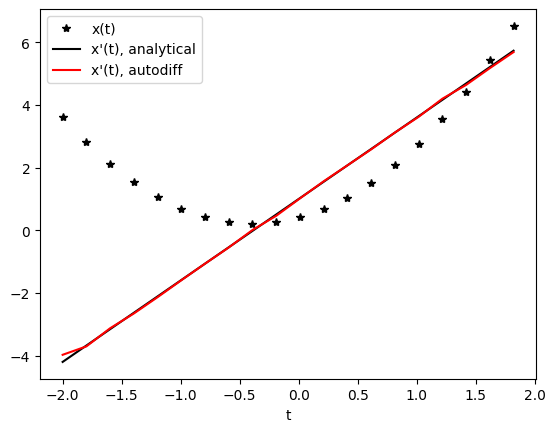

In [21]:
plt.plot(t[::10], x[::10], '*', color = 'k', label = 'x(t)')
plt.plot(t[::10], dx[::10], '-', color = 'k', label = "x'(t), analytical")
plt.plot(t[::10], dx_torch[::10], '-', color = 'r', label = "x'(t), autodiff")
plt.xlabel('t')
plt.legend()